# Домашняя работа №6 — кластеризация

**Данные простыми словами:** есть ~2240 клиентов розничной сети. У каждого — возраст, доход, образование, семейное положение, сколько потратил на вино/мясо/рыбу и т.д., как покупал (онлайн, в магазине, по каталогу).

**Задача:** разбить клиентов на группы (кластеры), чтобы каждую можно было назвать одним словом — «экономные», «премиум», «семейные».

Код разбит на модули (как в hw5). `main.py` прогоняет всё и сохраняет графики в `output/`. Здесь — по шагам вручную.

## 1. Импорт и загрузка

Если `data/marketing_campaign.csv` нет — скачается сам.

In [1]:
%matplotlib inline

from pathlib import Path

from modules import (
    ClusterBench,
    ClusterEvaluator,
    ClusterVisualizer,
    CustomerDataset,
    CustomerPreprocessor,
)
from modules.preprocessing import SPENDING_COLS

ROOT = Path('.').resolve()
DATA = ROOT / 'data'
OUT = ROOT / 'output'
K_BEST = 4
RANDOM_STATE = 42

dataset = CustomerDataset(DATA)
raw = dataset.load()
raw.head()

[CustomerDataset] rows=2240, cols=29, Income mean=52247, пропусков Income=24


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 2. EDA

In [2]:
preprocessor = CustomerPreprocessor()
eda = preprocessor.describe_eda(raw)
print('Пропуски:', dict(eda['missing']))
print('Константы:', eda['const_cols'])
eda['scale'].head(8)

Пропуски: {'Income': np.int64(24)}
Константы: ['Z_CostContact', 'Z_Revenue']


,min,max,mean,std,range
Income,1730.0,666666.0,52247.251354,25173.076661,664936.0
MntMeatProducts,0.0,1725.0,166.950000,225.715373,1725.0
MntWines,0.0,1493.0,303.935714,336.597393,1493.0
MntGoldProds,0.0,362.0,44.021875,52.167439,362.0
MntSweetProducts,0.0,263.0,27.062946,41.280498,263.0
MntFishProducts,0.0,259.0,37.525446,54.628979,259.0
MntFruits,0.0,199.0,26.302232,39.773434,199.0
Year_Birth,1893.0,1996.0,1968.805804,11.984069,103.0


[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\eda_distributions.png


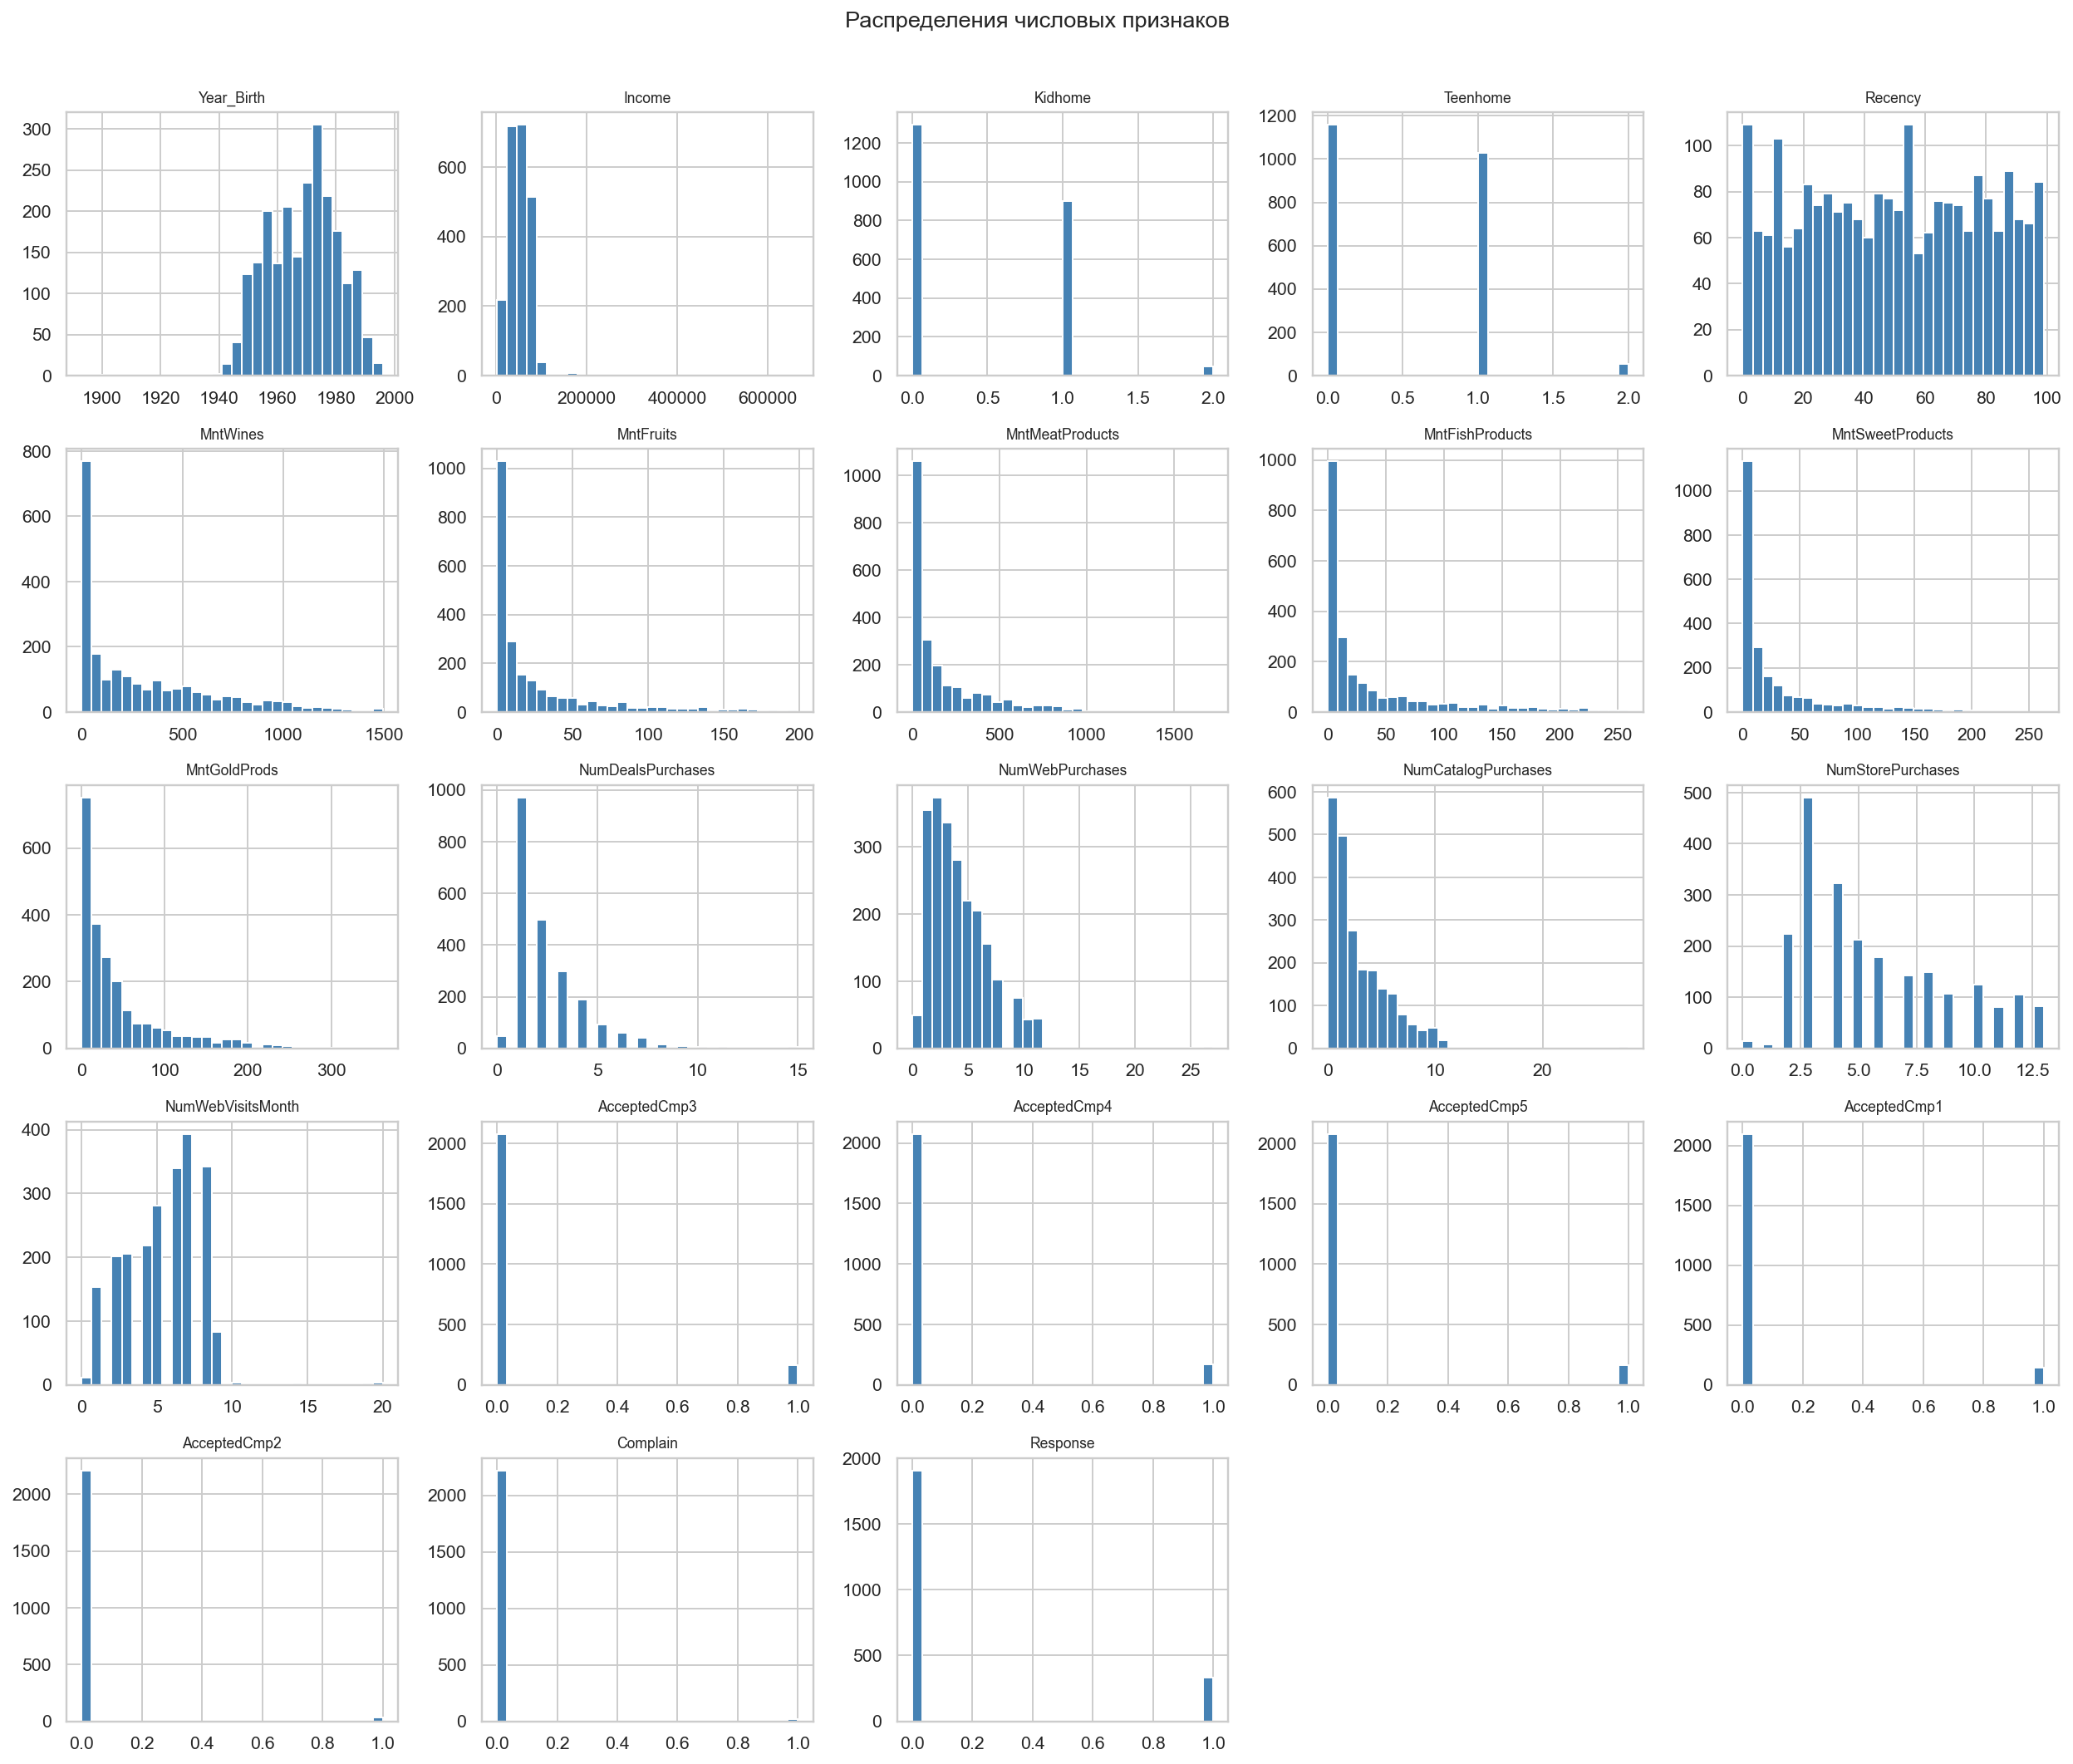

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\eda_spending_boxplots.png


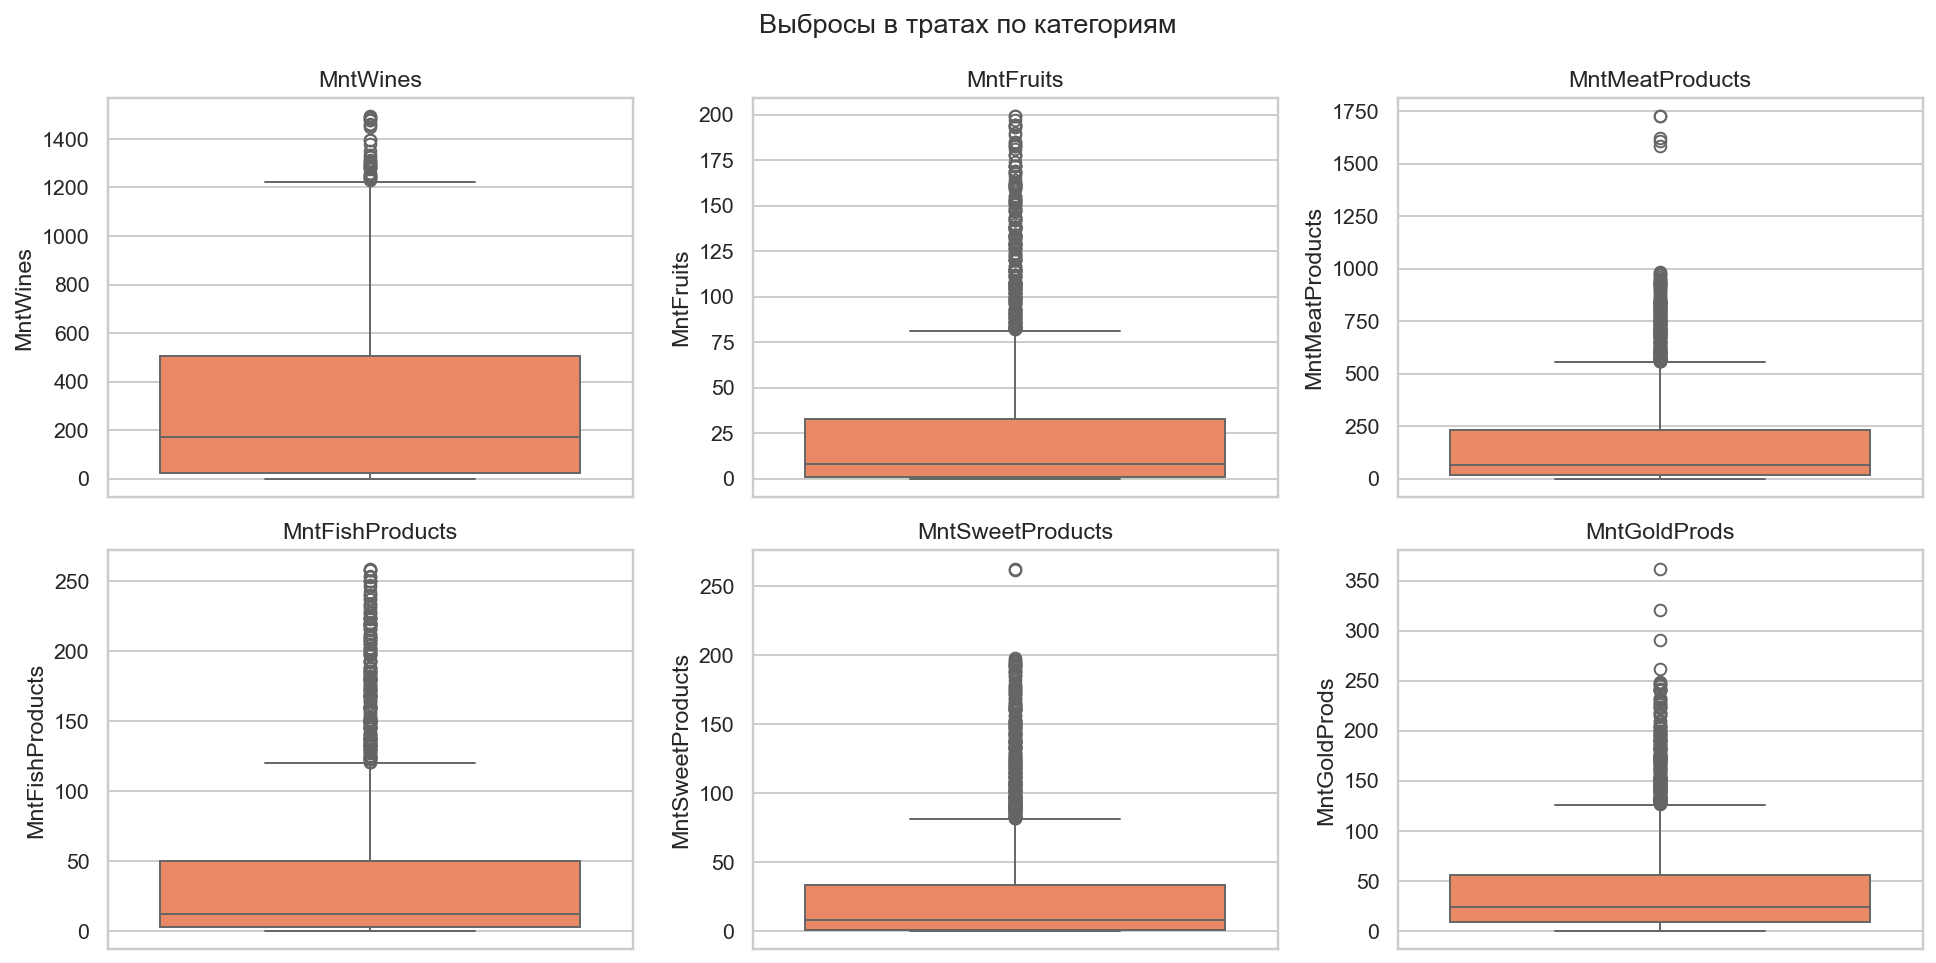

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\eda_correlation.png


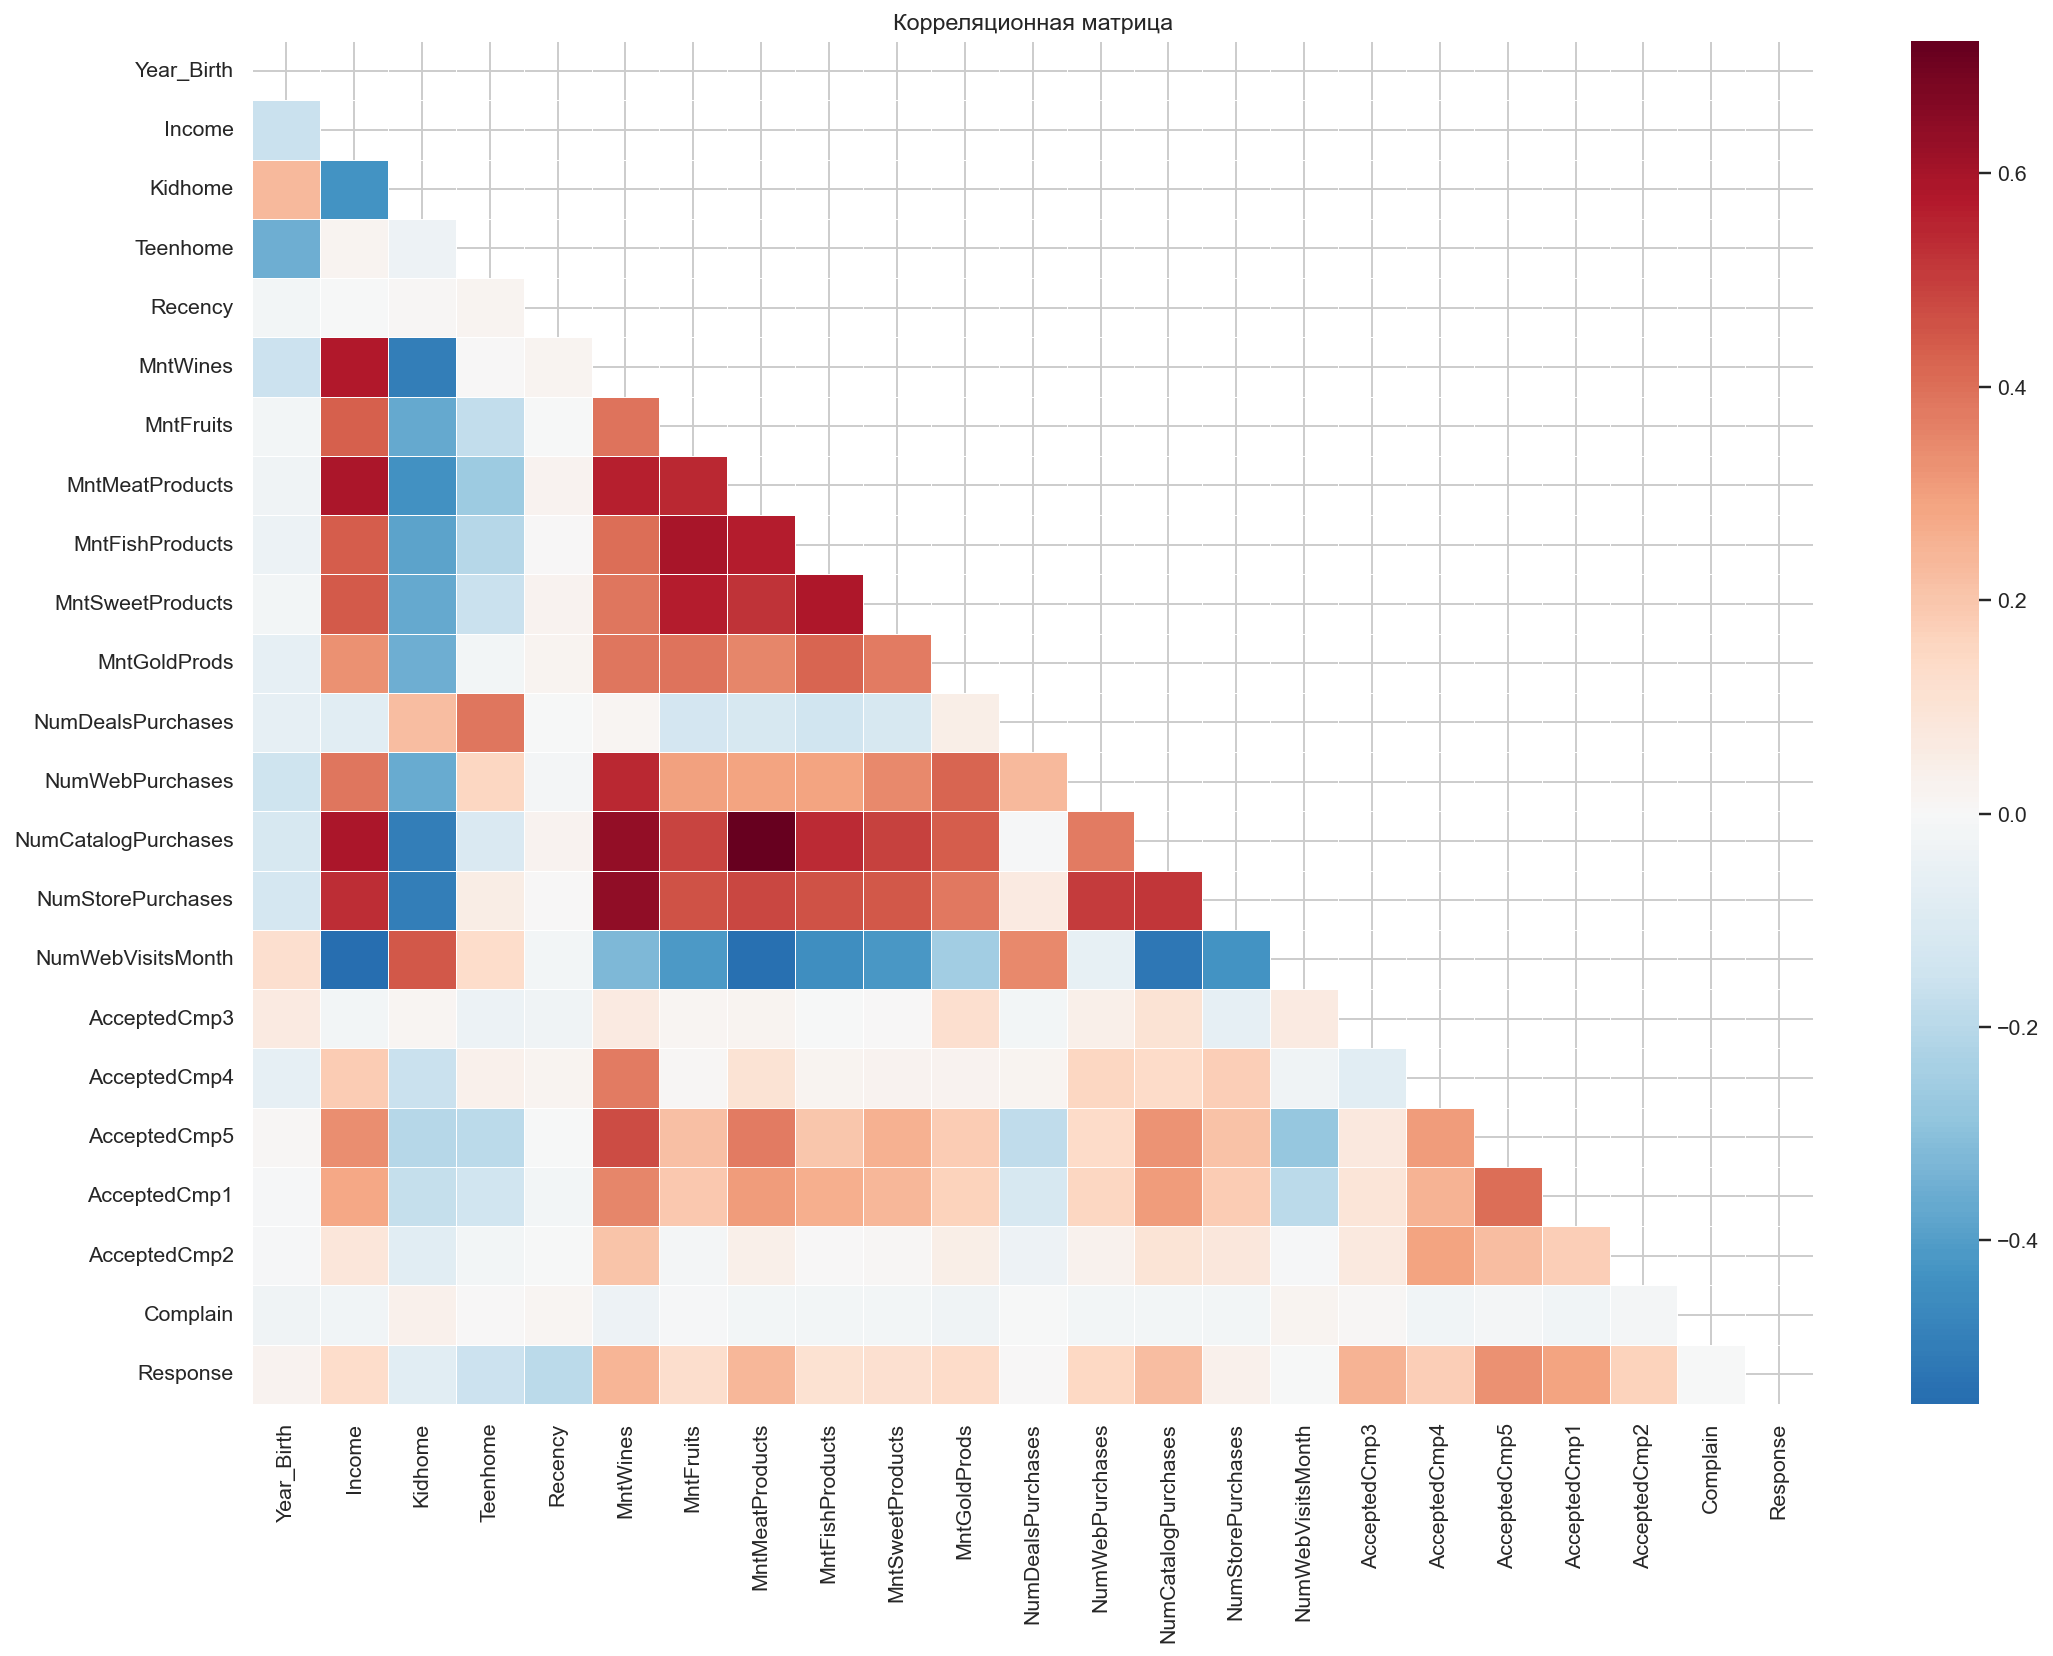

WindowsPath('C:/Users/Dezhurny/Desktop/Lesson6/output/eda_correlation.png')

In [3]:
viz = ClusterVisualizer(OUT)
viz.plot_numeric_distributions(raw, list(eda['num_cols']))
viz.plot_spending_boxplots(raw, SPENDING_COLS)
viz.plot_correlation_heatmap(raw, list(eda['num_cols']))

## 3–6. Предобработка

One-Hot + StandardScaler. Пропуски Income — флаг + медиана.

In [4]:
prepared = preprocessor.prepare(raw)
print(f'Признаков: {len(prepared.feature_names)}')
prepared.processed.head()

[Preprocessor] признаков=38, строк=2240, StandardScaler применён
Признаков: 38


,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Income_missing,Age,Customer_For,Total_Spending,Total_Purchases,Family_Size
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,0,0,0,1,0,67,36,1617,25,1
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,70,586,27,6,3
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,59,387,776,21,1
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,40,560,53,8,2
4,PhD,Married,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,0,43,538,422,19,2


## 7. Методы кластеризации

In [5]:
bench = ClusterBench(random_state=RANDOM_STATE)
results = bench.run_all(prepared.x, k=K_BEST)
bench.summary_table()

C:\Users\Dezhurny\AppData\Roaming\Python\Python310\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


,method,silhouette,n_clusters,n_noise
0,K-Means,0.141256,4,0
1,Agglomerative,0.089422,4,0
2,DBSCAN,0.194538,17,1628
3,HDBSCAN,0.186330,3,176
4,GMM,0.135068,4,0
5,Spectral,0.207781,4,0


[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\hierarchical_dendrogram.png


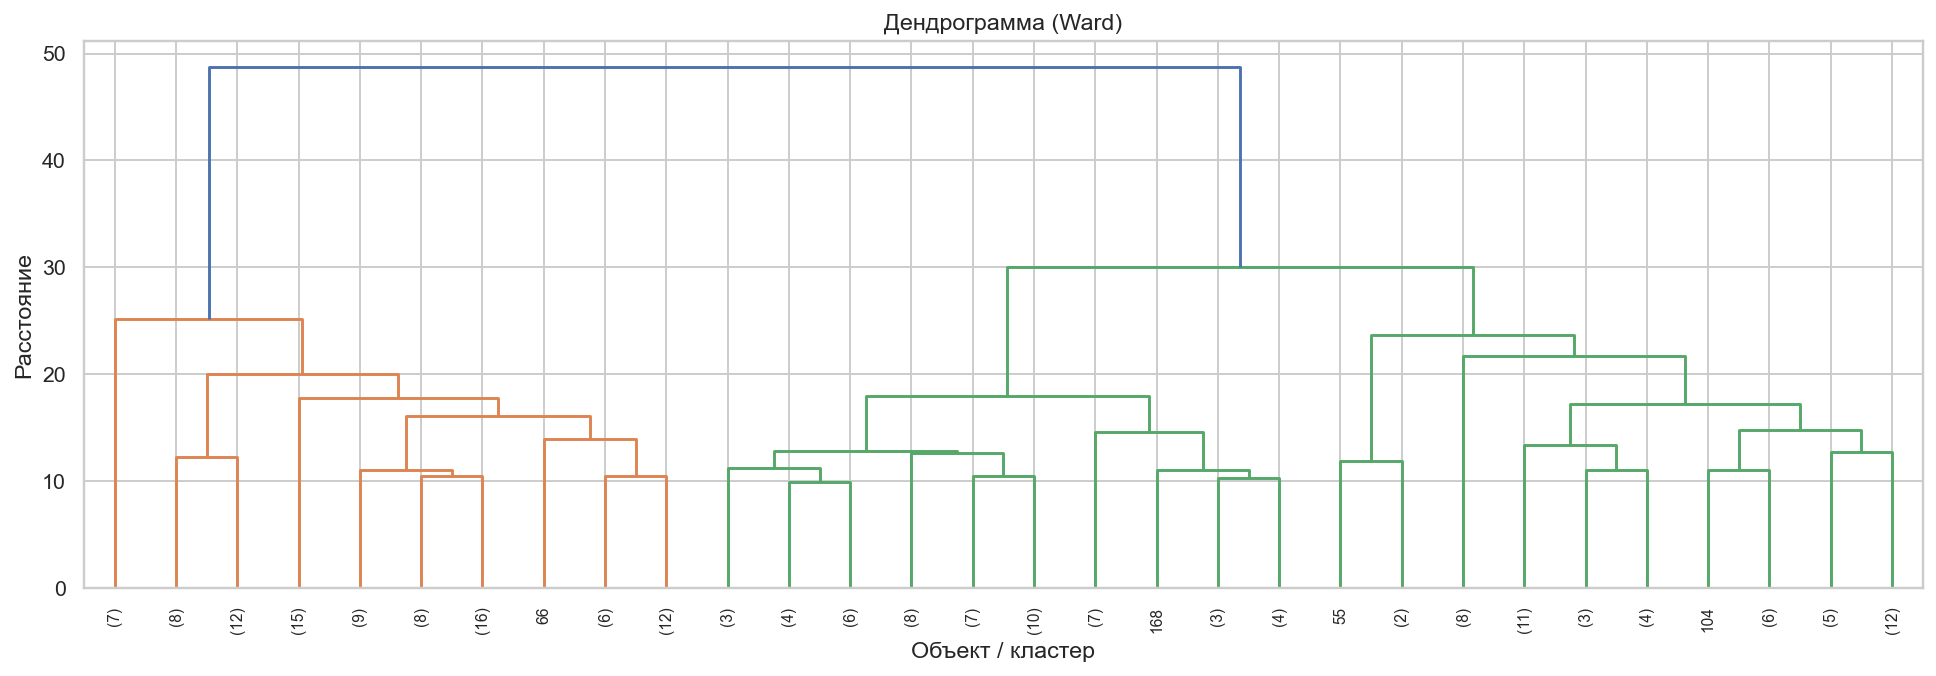

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\methods_silhouette.png


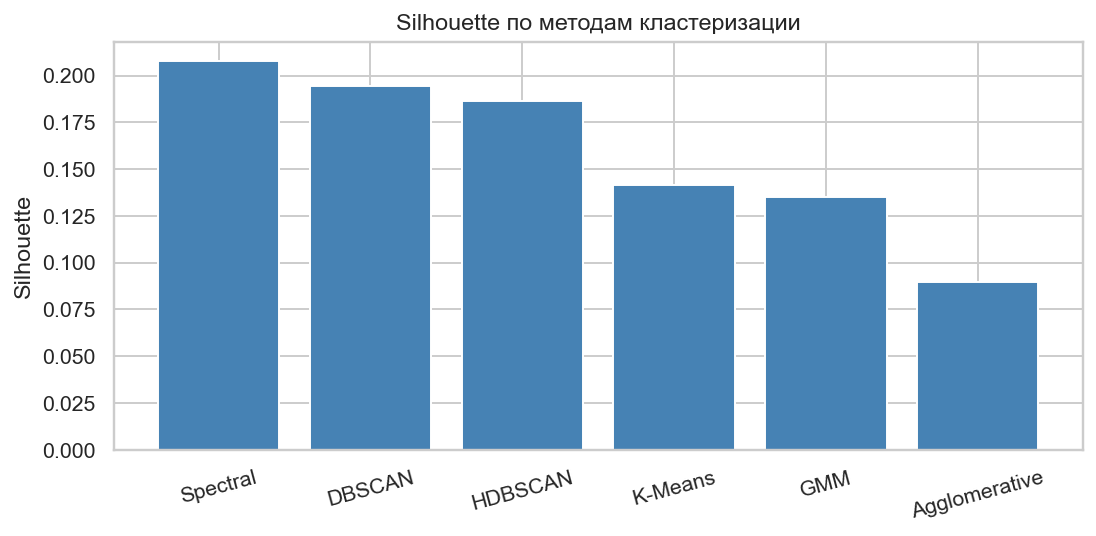

WindowsPath('C:/Users/Dezhurny/Desktop/Lesson6/output/methods_silhouette.png')

In [6]:
viz.plot_dendrogram(prepared.x, random_state=RANDOM_STATE)
viz.plot_methods_comparison(bench.summary_table())

## 8. Выбор k

[Evaluator] max silhouette при k=2, беру k=4 (интерпретируемость)
[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\k_selection.png


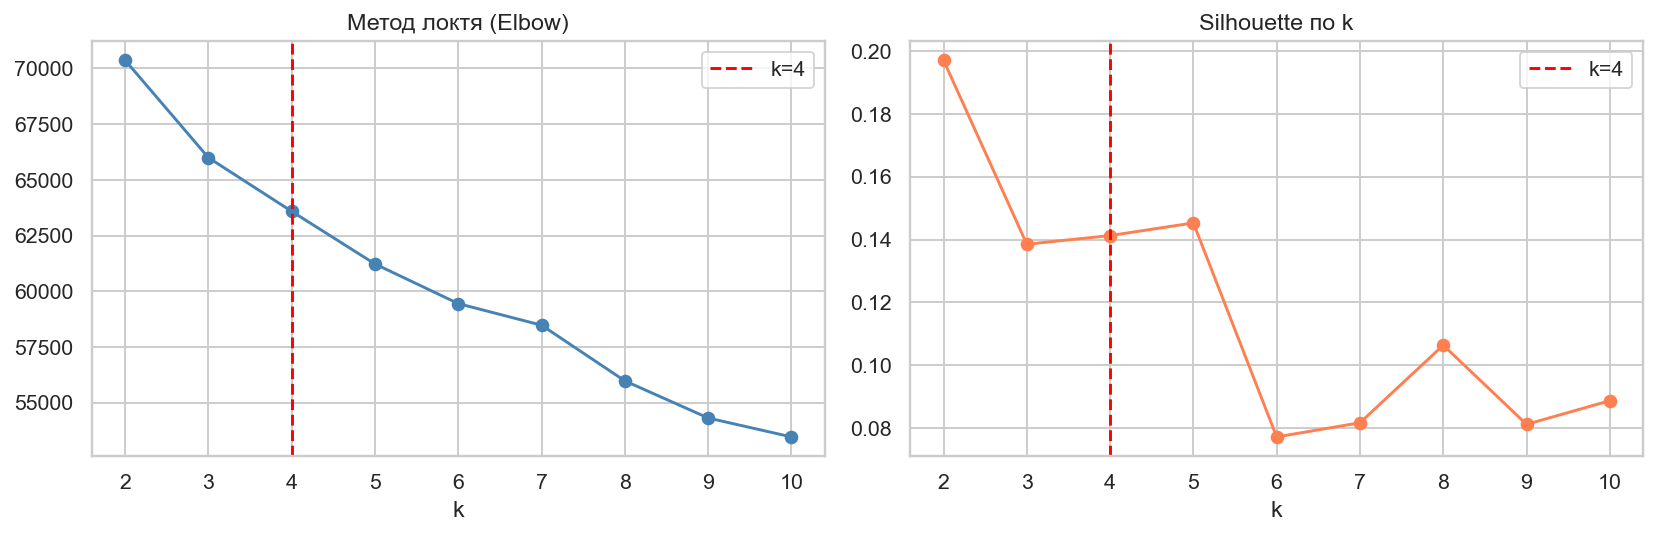

,Age,Income,Total_Spending,Total_Purchases,Recency,Family_Size,NumWebVisitsMonth,size
Cluster,,,,,,,,
0,55.9,71054.8,1307.7,19.9,48.7,1.5,5.2,30
1,52.5,35190.1,97.2,7.9,49.5,2.2,6.4,1038
2,59.4,57823.3,731.5,21.1,47.9,2.2,5.7,623
3,55.5,77104.2,1386.5,20.8,49.6,1.2,2.8,549


In [7]:
evaluator = ClusterEvaluator(random_state=RANDOM_STATE)
k_search = evaluator.search_k(prepared.x)
evaluator.pick_k(k_search, preferred=K_BEST)
viz.plot_k_search(k_search.k_range, k_search.inertias, k_search.silhouettes, k_best=K_BEST)

labels = results['K-Means'].labels
profile = evaluator.cluster_profile(prepared.processed, labels, prepared.profile_cols)
profile

## 9. Аномалии

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\anomalies_pca.png


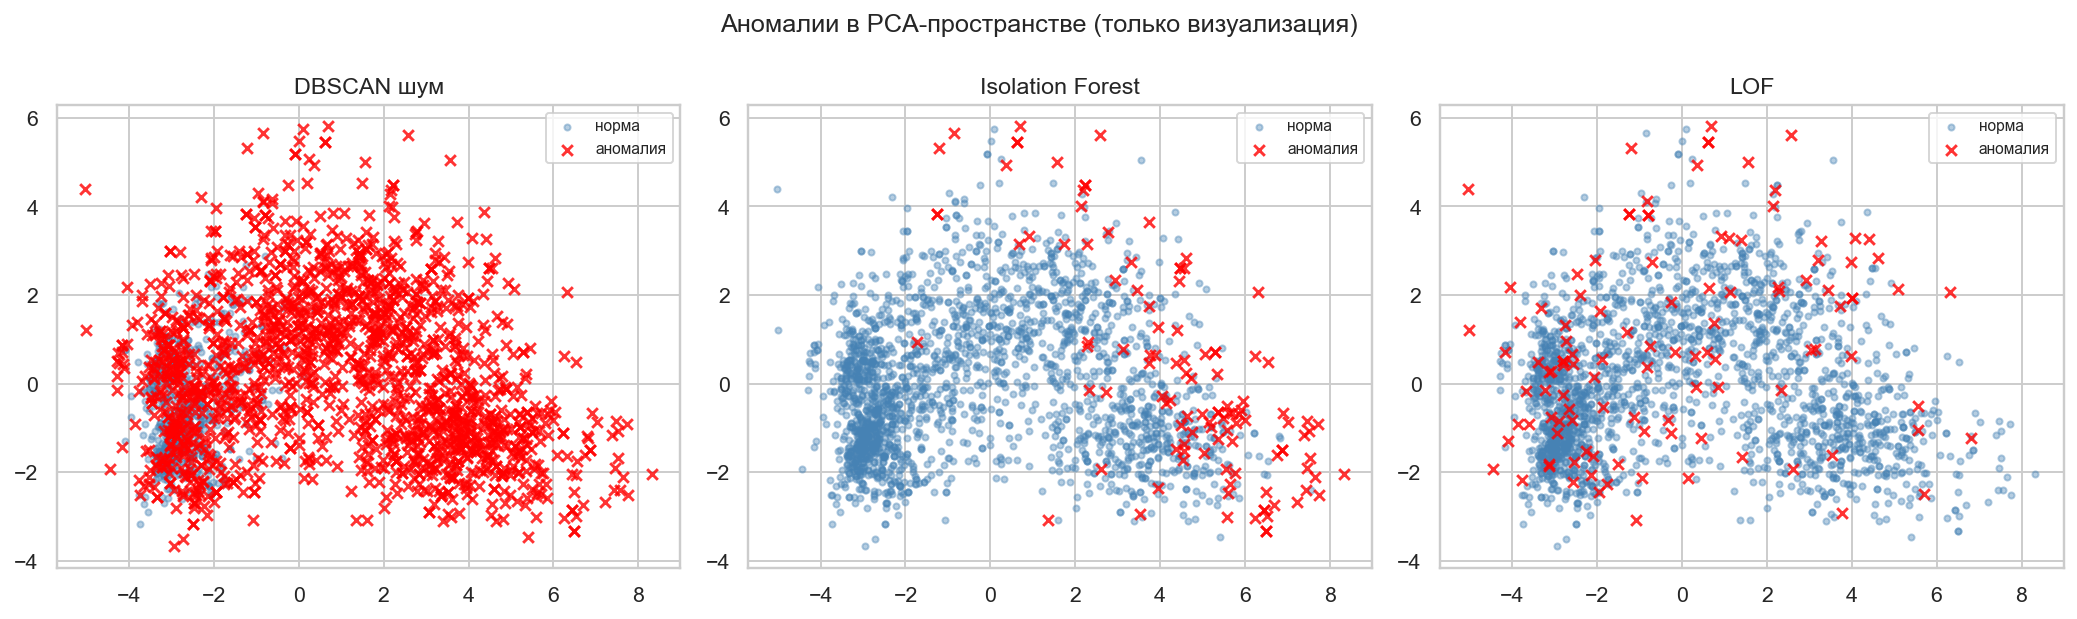

WindowsPath('C:/Users/Dezhurny/Desktop/Lesson6/output/anomalies_pca.png')

In [8]:
anomalies = evaluator.detect_anomalies(
    prepared.x, labels,
    results['DBSCAN'].labels,
    results['HDBSCAN'].labels,
)
anomalies.counts

viz.plot_anomalies_pca(
    prepared.x,
    {
        'DBSCAN шум': results['DBSCAN'].labels == -1,
        'Isolation Forest': anomalies.overlap['isolation_forest'].to_numpy(),
        'LOF': anomalies.overlap['lof'].to_numpy(),
    },
    random_state=RANDOM_STATE,
)

## 10. Визуализация

C:\Users\Dezhurny\AppData\Roaming\Python\Python310\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\projections_kmeans.png


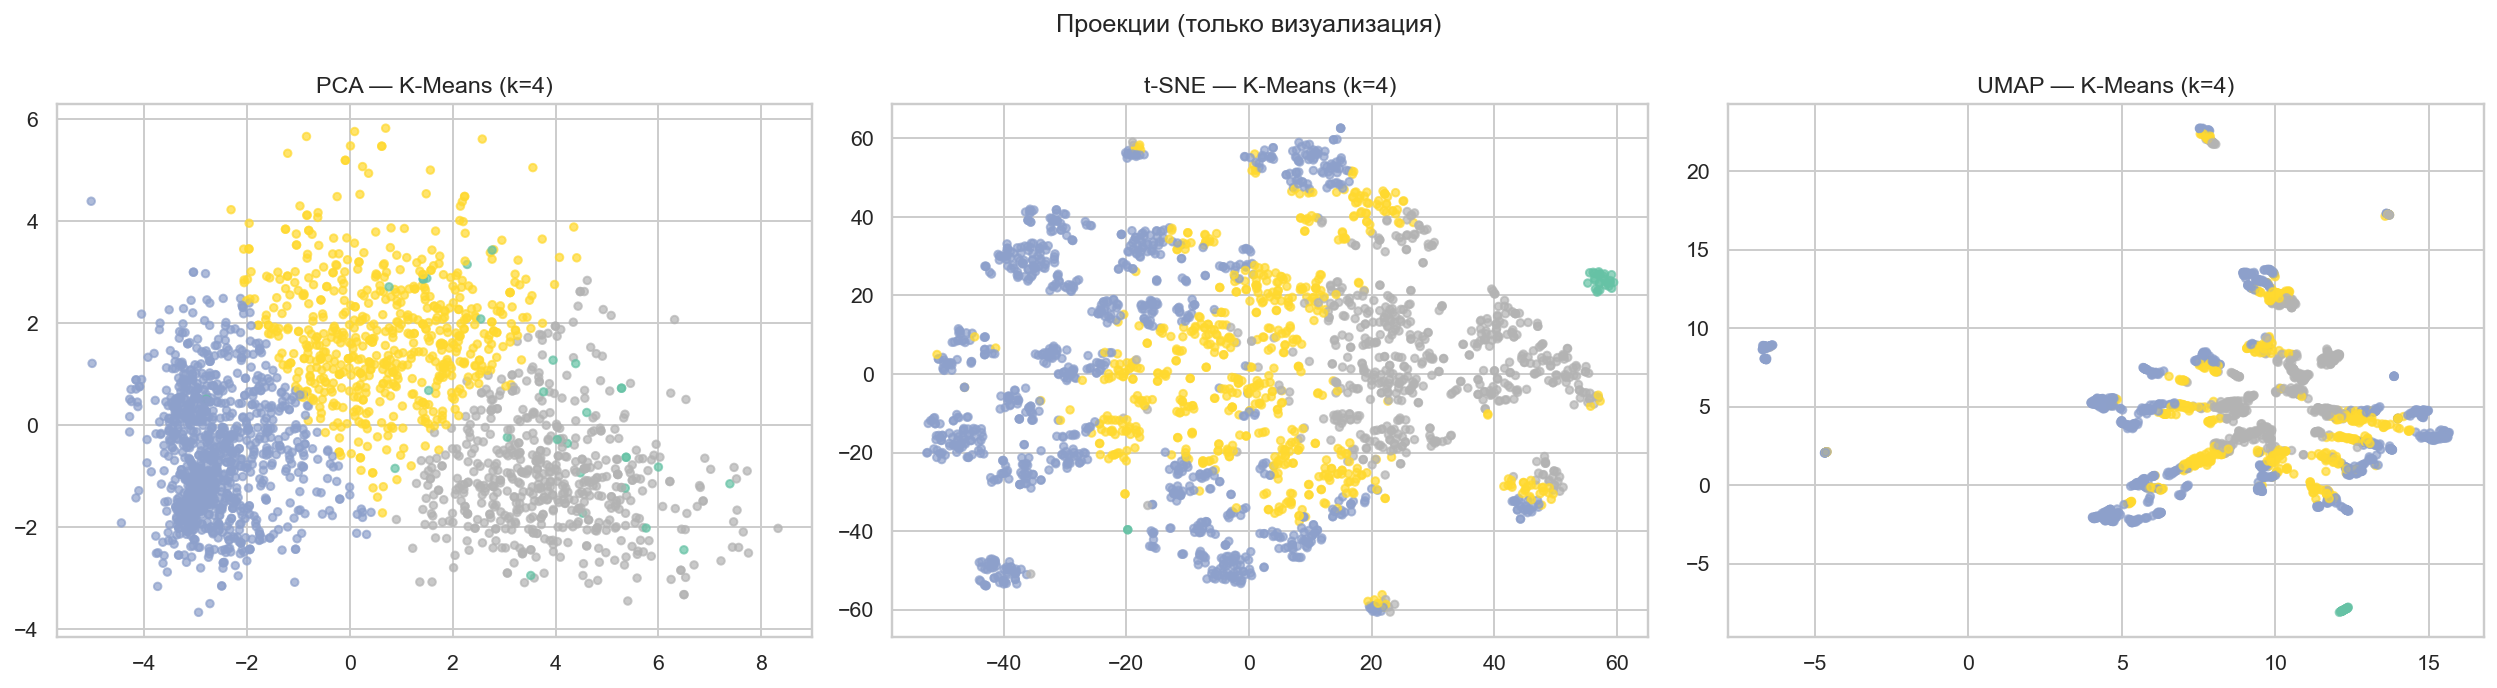

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\silhouette_plot.png


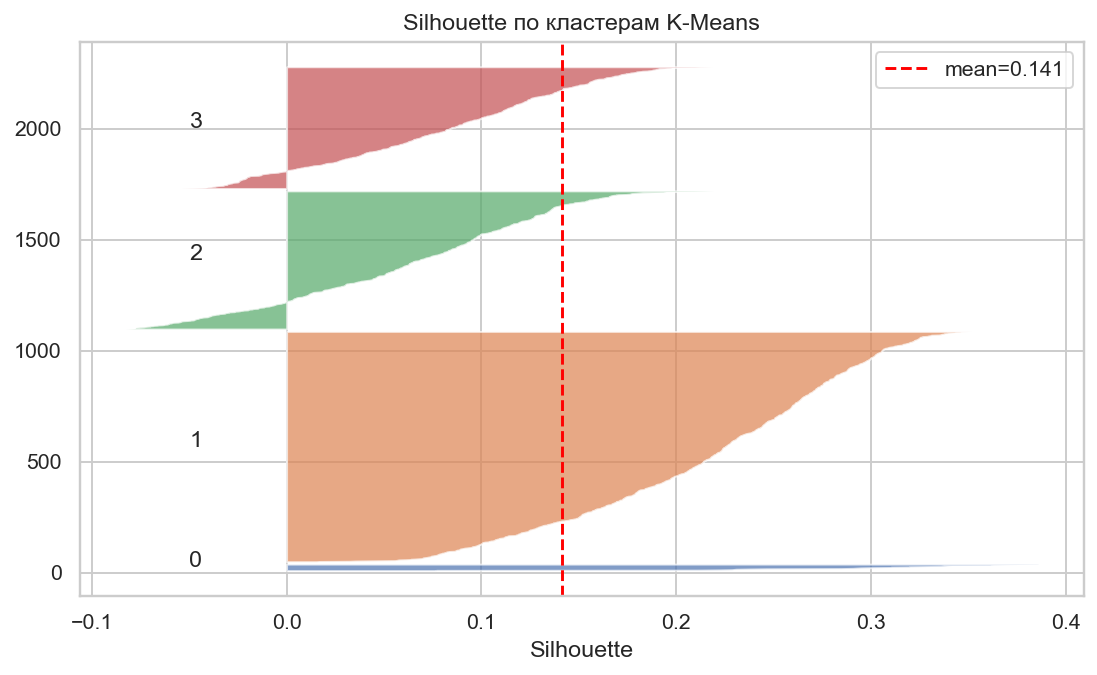

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\cluster_radar.png


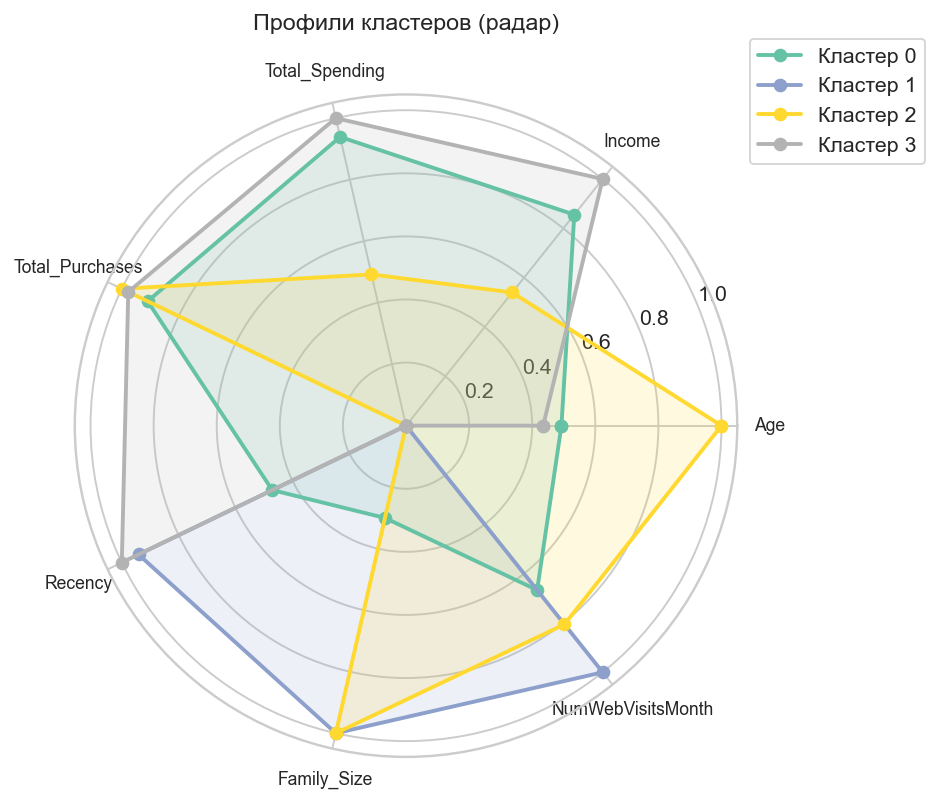

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\cluster_parallel_coords.png


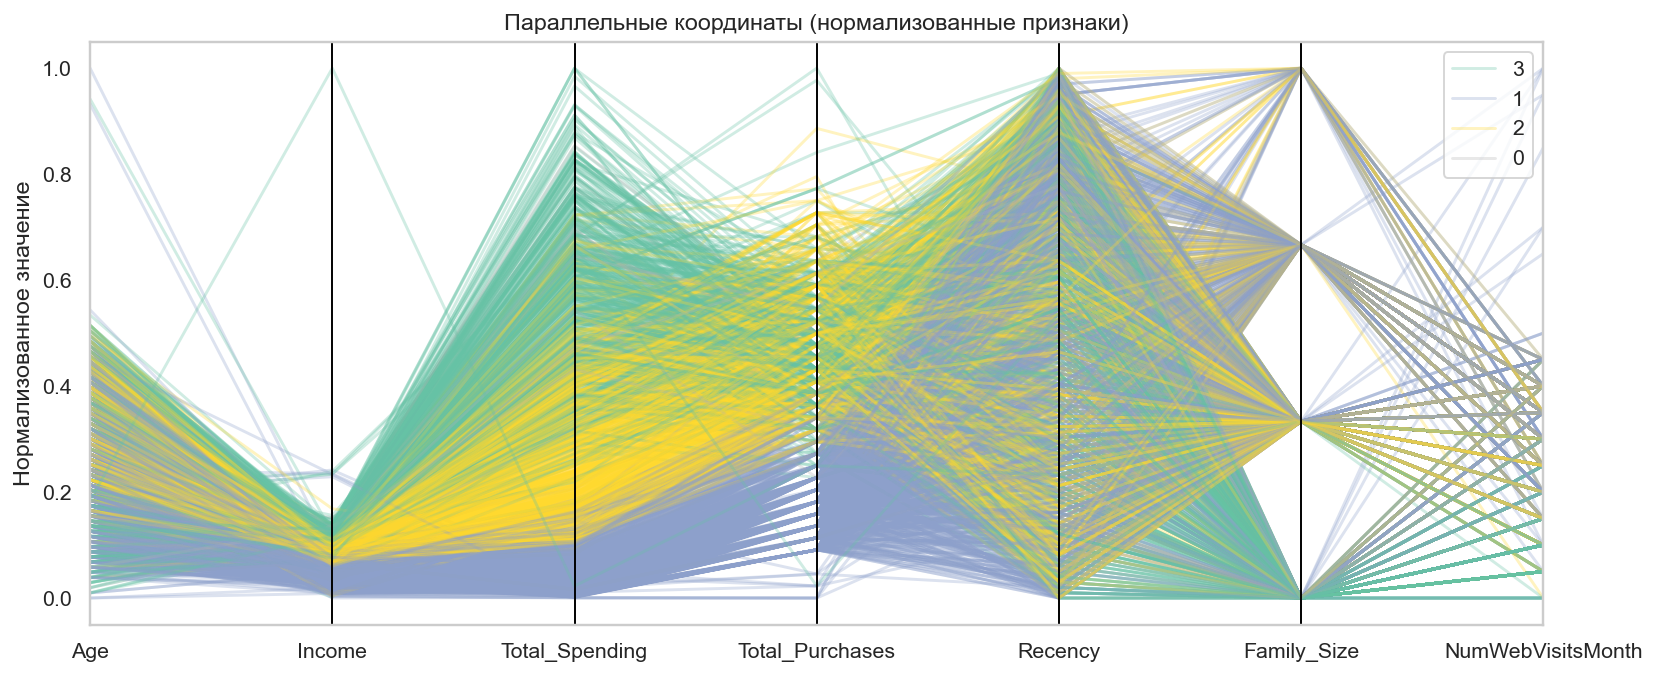

WindowsPath('C:/Users/Dezhurny/Desktop/Lesson6/output/cluster_parallel_coords.png')

In [9]:
viz.plot_projections(prepared.x, labels, k=K_BEST, random_state=RANDOM_STATE)
viz.plot_silhouette(prepared.x, labels, k=K_BEST)
viz.plot_radar_profiles(profile, list(prepared.profile_cols))
viz.plot_parallel_coordinates(prepared.processed, labels, list(prepared.profile_cols))

## Выводы

### Сегменты клиентов (K-Means, k=4)

| Кластер | Размер | Одним словом | Профиль |
|---------|--------|--------------|---------|
| 0 | ~30 | **VIP** | Высокий доход (~71k), очень большие траты (~1308), мало визитов на сайт |
| 1 | ~1038 | **Экономные** | Самая большая группа, низкие траты (~97), средний доход (~35k), чаще заходят на сайт |
| 2 | ~623 | **Средний сегмент** | Умеренный доход (~58k), средние траты (~732), активные покупатели |
| 3 | ~549 | **Премиум** | Высокий доход (~77k), максимальные траты (~1387), редко ходят на сайт — покупают офлайн/по каталогу |

Каждый кластер можно назвать одним словом — значит, данные подходят для кластеризации.

### Почему k=4

- **Silhouette** максимален при k=2, но два кластера — это просто «много тратят / мало тратят», слишком грубо.
- **Elbow** даёт изгиб около 3–4.
- При k=4 профили различимы и имеют бизнес-смысл — взял k=4, хотя метрика и предлагала k=2.

### Сравнение методов

- **Spectral** и **DBSCAN** дали выше silhouette, но DBSCAN пометил ~73% точек как шум — неудобно для маркетинга.
- **K-Means** проще интерпретировать: чёткие сегменты, нет метки «шум».
- **GMM** даёт мягкую принадлежность — полезно, если клиент на границе двух групп.

Для отчёта и рекомендаций взял **K-Means (k=4)**.

### Аномалии

- **Isolation Forest** и **LOF** согласны примерно на 112 объектах (~5%) — вероятные выбросы.
- **DBSCAN** слишком агрессивен (1628 шумовых точек) — параметр `eps` здесь не лучший индикатор аномалий.
- Кластер 0 (VIP, 30 человек) — отдельная малая группа с экстремальными тратами; часть из них попадает в аномалии по силуэту.

### Итог

Данные хорошо сегментируются. Основная масса клиентов — **экономный сегмент** (кластер 1). Для маркетинга имеет смысл разные кампании: скидки и онлайн-акции для кластера 1, премиум-предложения для кластеров 0 и 3, cross-sell для среднего сегмента (кластер 2).